Using data_root = C:\Users\devi0\Downloads\relay_dataset_auto
Exists?  True
Class "healthy" → folder = C:\Users\devi0\Downloads\relay_dataset_auto\healthy, #files = 100


C:\Users\devi0\.anaconda\idk\Lib\site-packages\scipy\io\matlab\_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


Class "correct_trip" → folder = C:\Users\devi0\Downloads\relay_dataset_auto\correct_trip, #files = 100
Class "missed_trip" → folder = C:\Users\devi0\Downloads\relay_dataset_auto\missed_trip, #files = 100
Class "delayed_trip" → folder = C:\Users\devi0\Downloads\relay_dataset_auto\delayed_trip, #files = 100
Class "false_trip" → folder = C:\Users\devi0\Downloads\relay_dataset_auto\false_trip, #files = 100

Total sequences loaded: 500
Max early-window sequence length (after downsampling) = 6286
X_seq_padded shape: (500, 6286, 6)
Y shape           : (500,)
Train samples: 400 Val samples: 100

=== Training Model: CNN + BiLSTM + Attention (early warning) ===


C:\Users\devi0\.anaconda\idk\Lib\site-packages\keras\src\layers\layer.py:938: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 172s 13s/step - accuracy: 0.5855 - loss: 0.6630 - val_accuracy: 0.6000 - val_loss: 0.6073
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 192s 15s/step - accuracy: 0.5855 - loss: 0.6168 - val_accuracy: 0.5900 - val_loss: 0.5621
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 190s 15s/step - accuracy: 0.7092 - loss: 0.5619 - val_accuracy: 0.8500 - val_loss: 0.5005
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 203s 16s/step - accuracy: 0.8814 - loss: 0.4808 - val_accuracy: 0.6800 - val_loss: 0.8402
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 245s 14s/step - accuracy: 0.8047 - loss: 0.5408 - val_accuracy: 0.8800 - val_loss: 0.4279
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 199s 15s/step - accuracy: 0.9019 - loss: 0.3860 - val_accuracy: 0.9200 - val_loss: 0.3606
Epoch 7/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 199s 15s/step - accuracy: 0.9364 - loss: 0.2932 - val_accuracy: 0.9200 - val_loss: 0.3304
Epoch 8/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 227s 18s/step - accuracy: 0.9385 - loss: 0.2483 - val_accuracy: 0.

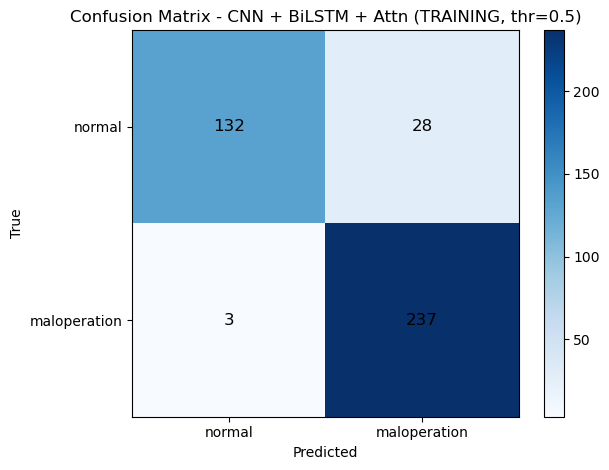

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 757ms/step

--- CNN + BiLSTM + Attn (VALIDATION, thr=0.5) ---
Confusion matrix (rows = true, cols = pred):
[[33  7]
 [ 1 59]]
Accuracy       : 0.920
Precision (normal, maloperation): [0.97058824 0.89393939]
Recall    (normal, maloperation): [0.825      0.98333333]
F1        (normal, maloperation): [0.89189189 0.93650794]
Macro F1-score: 0.914


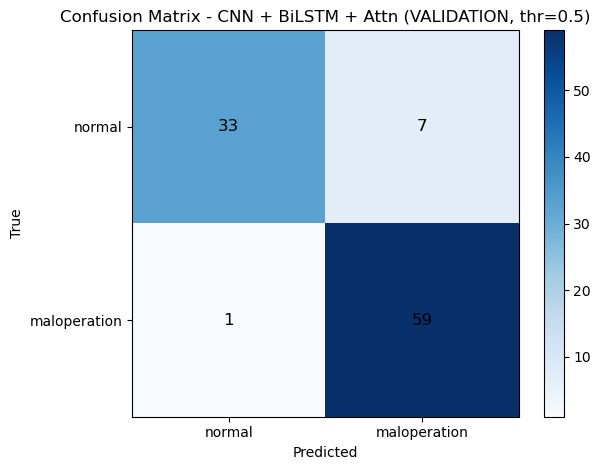

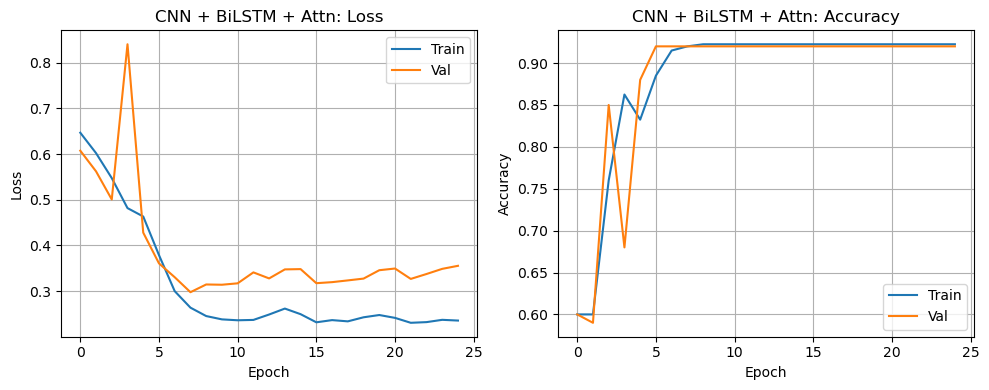


=== DONE: EARLY WARNING CNN + BiLSTM + ATTENTION MODEL ===
TRAINING metrics: {'cm': array([[132,  28],
       [  3, 237]], dtype=int64), 'accuracy': 0.9225, 'precision': array([0.97777778, 0.89433962]), 'recall': array([0.825 , 0.9875]), 'f1': array([0.89491525, 0.93861386]), 'macro_f1': 0.9167645578117134}
VALIDATION metrics: {'cm': array([[33,  7],
       [ 1, 59]], dtype=int64), 'accuracy': 0.92, 'precision': array([0.97058824, 0.89393939]), 'recall': array([0.825     , 0.98333333]), 'f1': array([0.89189189, 0.93650794]), 'macro_f1': 0.9141999141999142}


In [1]:
import random
import os
import glob
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Masking, Conv1D, MaxPooling1D,
    Bidirectional, LSTM, Dense,
    Attention, GlobalAveragePooling1D, Concatenate  # <-- NEW
)
from tensorflow.keras.utils import to_categorical   # <-- fixed typo

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

data_root = r"C:\Users\devi0\Downloads\relay_dataset_auto"
original_classes = ["healthy", "correct_trip", "missed_trip", "delayed_trip", "false_trip"]

print("Using data_root =", data_root)
print("Exists? ", os.path.exists(data_root))

X_seq_list = []   # sequences (early window, downsampled)
Y_list = []       # 0 or 1

early_fraction = 0.5   # first 50% of waveform
ds_factor = 4          # stronger downsampling → faster

for cls in original_classes:
    folder = os.path.join(data_root, cls)
    files = glob.glob(os.path.join(folder, "*.mat"))
    print(f'Class "{cls}" → folder = {folder}, #files = {len(files)}')

    # Map original class to binary label
    if cls in ["healthy", "correct_trip"]:
        label_idx = 0   # normal
    else:
        label_idx = 1   # maloperation

    for fpath in files:
        mat = sio.loadmat(fpath)

        # Prefer Xcurr + Xvolt, fallback to X_all
        if "Xcurr" in mat:
            Xseq = mat["Xcurr"]
            if "Xvolt" in mat and mat["Xvolt"].size > 0:
                Xseq = np.concatenate([Xseq, mat["Xvolt"]], axis=1)
        elif "X_all" in mat:
            Xseq = mat["X_all"]
        else:
            print(f"  WARNING: {os.path.basename(fpath)} has no Xcurr or X_all → skipping.")
            continue

        Xseq = np.array(Xseq, dtype=np.float32)
        if Xseq.ndim > 2:
            Xseq = np.squeeze(Xseq)
        if Xseq.size == 0:
            print(f"  WARNING: {os.path.basename(fpath)} empty → skipping.")
            continue

        # EARLY WINDOW
        T = Xseq.shape[0]
        early_len = max(50, int(early_fraction * T))  # at least 50 samples
        early_len = min(early_len, T)
        X_early = Xseq[:early_len, :]                 # (early_len, features)

        # DOWNSAMPLE
        X_early_ds = X_early[::ds_factor, :]          # (T', features)

        X_seq_list.append(X_early_ds)
        Y_list.append(label_idx)

if len(X_seq_list) == 0:
    raise RuntimeError("No sequences loaded. Check data_root path and folder structure.")

print(f"\nTotal sequences loaded: {len(X_seq_list)}")

lengths = [x.shape[0] for x in X_seq_list]
max_len = max(lengths)
print(f"Max early-window sequence length (after downsampling) = {max_len}")

def pad_sequence(seq, max_len):
    t, f = seq.shape
    if t >= max_len:
        return seq[:max_len, :]
    padded = np.zeros((max_len, f), dtype=np.float32)
    padded[:t, :] = seq
    return padded

X_seq_padded = np.stack([pad_sequence(x, max_len) for x in X_seq_list], axis=0)  # (N, max_len, features)
Y = np.array(Y_list, dtype=np.int64)

print("X_seq_padded shape:", X_seq_padded.shape)
print("Y shape           :", Y.shape)

num_classes  = 2
num_features = X_seq_padded.shape[2]
class_names  = ["normal", "maloperation"]

X_train, X_val, y_train, y_val = train_test_split(
    X_seq_padded, Y, test_size=0.2, random_state=42, stratify=Y
)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat   = to_categorical(y_val,   num_classes=num_classes)

print("Train samples:", X_train.shape[0], "Val samples:", X_val.shape[0])


# MODEL: CNN + BiLSTM + ATTENTION

def build_cnn_bilstm_attention(num_features, num_classes, max_len):
    """
    CNN + BiLSTM + Self-Attention model for early-warning.
    Input shape: (max_len, num_features)
    """
    inputs = Input(shape=(max_len, num_features))

    # Ignore padded zeros
    x = Masking(mask_value=0.0)(inputs)

    # CNN feature extractor
    x = Conv1D(filters=32, kernel_size=5, activation="relu", padding="same")(x)
    x = MaxPooling1D(pool_size=2)(x)

    # BiLSTM sequence encoder (keep sequence for attention)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)

    # Self-attention over time
    attn_out = Attention()([x, x])           # (batch, time, features)
    x = Concatenate()([x, attn_out])         # combine original + attended features

    # Pool over time to get single feature vector
    x = GlobalAveragePooling1D()(x)

    # Fully-connected layers
    x = Dense(32, activation="relu")(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        loss="categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return model

batch_size = 32
epochs = 25   

print("\n=== Training Model: CNN + BiLSTM + Attention (early warning) ===")
model = build_cnn_bilstm_attention(num_features, num_classes, max_len)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

print("\nFinal TRAIN accuracy:", history.history["accuracy"][-1])
print("Final VAL accuracy  :", history.history["val_accuracy"][-1])


# EVALUATION 

def evaluate_binary(y_true, y_pred, name="model"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = np.mean(f1)

    print(f"\n--- {name} ---")
    print("Confusion matrix (rows = true, cols = pred):")
    print(cm)
    print(f"Accuracy       : {acc:.3f}")
    print(f"Precision (normal, maloperation): {precision}")
    print(f"Recall    (normal, maloperation): {recall}")
    print(f"F1        (normal, maloperation): {f1}")
    print(f"Macro F1-score: {macro_f1:.3f}")

    # Confusion matrix plot with numbers
    plt.figure()
    plt.imshow(cm, cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.colorbar()
    plt.xticks([0, 1], ["normal", "maloperation"])
    plt.yticks([0, 1], ["normal", "maloperation"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]),
                     ha="center", va="center", color="black", fontsize=12)
    plt.tight_layout()
    plt.show()

    return {
        "cm": cm,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "macro_f1": macro_f1
    }

# TRAINING ACCURACY 
probs_train = model.predict(X_train)
threshold = 0.5
y_pred_train = (probs_train[:, 1] > threshold).astype(int)
metrics_train = evaluate_binary(
    y_train, y_pred_train,
    name=f"CNN + BiLSTM + Attn (TRAINING, thr={threshold})"
)

# validation metrics
probs_val = model.predict(X_val)
y_pred_val = (probs_val[:, 1] > threshold).astype(int)
metrics_val = evaluate_binary(
    y_val, y_pred_val,
    name=f"CNN + BiLSTM + Attn (VALIDATION, thr={threshold})"
)


# TRAINING CURVES

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN + BiLSTM + Attn: Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train")
if "val_accuracy" in history.history:
    plt.plot(history.history["val_accuracy"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN + BiLSTM + Attn: Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n=== DONE: EARLY WARNING CNN + BiLSTM + ATTENTION MODEL ===")
print("TRAINING metrics:", metrics_train)
print("VALIDATION metrics:", metrics_val)


In [2]:

print("\n================ EARLY WARNING DECISIONS (VALIDATION) ================\n")

for i in range(len(y_val)):
    true_label = "normal" if y_val[i] == 0 else "maloperation"
    pred_label = "normal" if y_pred_val[i] == 0 else "maloperation"

    print(f"Sample {i+1}: True = {true_label}, Predicted = {pred_label}")
    if y_pred_val[i] == 1:
        print("  ⚠️ EARLY WARNING: Relay maloperation likely! Please check the system.\n")
    else:
        print("  ✔️ System healthy — relay operating normally.\n")



================ EARLY WARNING DECISIONS (VALIDATION) ================

Sample 1: True = maloperation, Predicted = maloperation
  ⚠️ EARLY WARNING: Relay maloperation likely! Please check the system.

Sample 2: True = maloperation, Predicted = maloperation
  ⚠️ EARLY WARNING: Relay maloperation likely! Please check the system.

Sample 3: True = normal, Predicted = normal
  ✔️ System healthy — relay operating normally.

Sample 4: True = normal, Predicted = normal
  ✔️ System healthy — relay operating normally.

Sample 5: True = maloperation, Predicted = maloperation
  ⚠️ EARLY WARNING: Relay maloperation likely! Please check the system.

Sample 6: True = normal, Predicted = maloperation
  ⚠️ EARLY WARNING: Relay maloperation likely! Please check the system.

Sample 7: True = maloperation, Predicted = normal
  ✔️ System healthy — relay operating normally.

Sample 8: True = normal, Predicted = normal
  ✔️ System healthy — relay operating normally.

Sample 9: True = normal, Predicted = ma

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 766ms/step


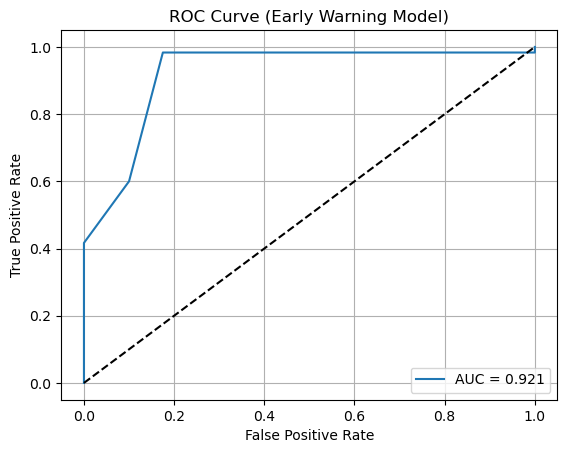

In [4]:
from sklearn.metrics import roc_curve, auc

# For ROC, use predicted probability of class 1
probs = model.predict(X_val)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Early Warning Model)")
plt.legend()
plt.grid(True)
plt.show()
